In [1]:
# import typing and operator
from __future__ import annotations
import json
import operator
import os
import re
from typing import List, Annotated, TypedDict, Optional, Literal
from pathlib import Path
from datetime import date, timedelta

# import llm, messages, OutputParser
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

# import langgraph orchastrator, search engine and dotnev
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langgraph.checkpoint.memory import InMemorySaver, RunnableConfig
from langchain_community.tools.tavily_search import TavilySearchResults

from google import genai
from google.genai import types

from dotenv import load_dotenv
load_dotenv()

c:\Users\Arbaz Khan\Desktop\Langgraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0.6)

In [3]:
llm.invoke("what is Agent")

AIMessage(content="An agent is an entity that acts on behalf of another entity, often referred to as the principal. Agents can be individuals or organizations that are authorized to make decisions, take actions, and interact with other entities in a specific context. Here are some common types of agents:\n\n1. **Human Agent**: A person who acts on behalf of another person or organization, such as a sales agent, real estate agent, or travel agent.\n2. **Software Agent**: A computer program that acts autonomously to perform a specific task, such as a chatbot, virtual assistant, or a robotic process automation (RPA) agent.\n3. **Intelligent Agent**: A software agent that uses artificial intelligence (AI) and machine learning (ML) to make decisions and take actions, such as a self-driving car's autonomous driving system.\n4. **Autonomous Agent**: A software agent that can operate independently without human intervention, such as a drone or a robot.\n\nAgents can have various characteristic

### Pydantic models

In [4]:
class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ..., 
        description="One sentence describing what the reader should be able to do/understand after this section."
    )
    bullets: List[str] = Field(
        ...,
        description="3-5 concrete, non-overlapping subpoints to cover in this section.",
        min_length=3,
        max_length=5,
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450)."
    )
    section_type: Literal["intro", "core", "examples", "checklist", "common_mistakes", "conclusion"] = Field(
        ...,
        description="Use 'common_mistakes' exactly once in the plan.",
    )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


In [5]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

In [6]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None

In [7]:
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    reason: str
    queries: List[str] = Field(default_factory=list)
    max_results_per_query: int = Field(3, description="How many results to fetch per query (3-6).")

In [8]:
class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [9]:
class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)

In [10]:
class BlogState(TypedDict):
    topic: str
    
    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

     # NEW: recency control
    as_of: str           # ISO date, e.g. "2026-01-29"
    recency_days: int    # 7 for weekly news, 30 for hybrid, etc.
    
    # reducer/image
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]
    
    sections: Annotated[List[str], operator.add]
    final: Optional[str]

### Tools

In [11]:
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    """
    Uses TavilySearchResults if installed and TAVILY_API_KEY is set.
    Returns list of dict with common fields. Note: published date is often missing.
    """
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized

def _iso_to_date(s: Optional[str]) -> Optional[date]:
    if not s:
        return None
    try:
        return date.fromisoformat(s[:10])
    except Exception:
        return None

### Nodes

In [12]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.

Output JSON only with keys:
- needs_research (boolean)
- mode ("closed_book" | "hybrid" | "open_book")
- reason (string)
- queries (array of strings)
- max_results_per_query (integer)
Do not quote booleans or integers.
"""

def _coerce_bool(value) -> bool:
    if isinstance(value, bool):
        return value
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes", "y"}
    return bool(value)

def _coerce_int(value, default: int = 3) -> int:
    try:
        return int(value)
    except Exception:
        return default

def _extract_json(text: str) -> Optional[str]:
    if not text:
        return None
    stripped = text.strip()
    if stripped.startswith("{") and stripped.endswith("}"):
        return stripped
    start = stripped.find("{")
    end = stripped.rfind("}")
    if start != -1 and end != -1 and end > start:
        return stripped[start : end + 1]
    return None

def router_node(state: BlogState) -> dict:
    topic = state["topic"]
    raw = llm.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}\nAS-of date: {state['as_of']}"),
        ]
    ).content
    raw_json = _extract_json(raw)
    if raw_json is None:
        repaired = llm.invoke(
            [
                SystemMessage(content="Return only valid JSON for RouterDecision."),
                HumanMessage(content=raw),
            ]
        ).content
        raw_json = _extract_json(repaired)
    if raw_json is None:
        raise ValueError("Router returned non-JSON response.")
    try:
        decision = RouterDecision.model_validate_json(raw_json)
    except Exception:
        data = json.loads(raw_json)
        data["needs_research"] = _coerce_bool(data.get("needs_research"))
        data["max_results_per_query"] = _coerce_int(data.get("max_results_per_query"), 3)
        decision = RouterDecision.model_validate(data)

    if decision.mode == "open_book":
        recency_days = 7
    elif decision.mode == "hybrid":
        recency_days = 45
    else:
        recency_days = 3650

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
        "recency_days": recency_days
    }

def route_next(state: BlogState) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [13]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- Extract/normalize published_at as ISO (YYYY-MM-DD) if you can infer it from title/snippet.
  If you can't infer a date reliably, set published_at=null (do NOT guess).
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: BlogState) -> dict:

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 4

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=(
                f"As-of date: {state['as_of']}\n"
                f"Recency days: {state['recency_days']}\n\n"
                f"Raw results:\n{raw_results}"
            )),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e
    evidence = list(dedup.values())

    # HARD RECENCY FILTER for open_book weekly roundup:
    # keep only items with a parseable ISO date and within the window.
    mode = state.get("mode", "closed_book")
    if mode == "open_book":
        as_of = date.fromisoformat(state["as_of"])
        cutoff = as_of - timedelta(days=int(state["recency_days"]))
        fresh: List[EvidenceItem] = []
        for e in evidence:
            d = _iso_to_date(e.published_at)
            if d and d >= cutoff:
                fresh.append(e)
        evidence = fresh

    return {"evidence": evidence}

In [14]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Flexibility:
- Do NOT use a fixed taxonomy unless it naturally fits.
- You may tag tasks (tags field), but tags are flexible.

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book (weekly news roundup):
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections (no scraping/RSS/how to fetch news) unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient fresh sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: BlogState) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    forced_kind = "news_roundup" if mode == "open_book" else None

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {state['as_of']} (recency_days={state['recency_days']})\n"
                    f"{'Force blog_kind=news_roundup' if forced_kind else ''}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}\n\n"
                    f"Instruction: If mode=open_book, your plan must NOT drift into a tutorial."
                )
            ),
        ]
    )

    return {"plan": plan}

In [15]:
# special node, the fanout function is use when we don't know how many times we want to call a function in parallel.
def fanout(state: BlogState):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
                "as_of": state["as_of"],
                "recency_days": state["recency_days"]
            },
        )
        for task in state["plan"].tasks
    ]

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard (prevents mid-blog topic drift):
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book (weekly news):
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true (hybrid sections):
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning (concepts, intuition) is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload: dict) -> dict:
    
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")
    as_of = payload.get("as_of")
    recency_days = payload.get("recency_days")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    # Provide a compact evidence list for citation use
    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n"
                    f"As-of: {as_of} (recency_days={recency_days})\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                ),
            ),
        ],
    ).content.strip()

    # deterministic ordering
    return {"sections": [(task.id, section_md)]}

### Reducer subgraph

In [23]:
def merge_content(state: BlogState) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}

DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.
"""

def _truncate_for_images(md: str, max_chars: int = 12000) -> str:
    if len(md) <= max_chars:
        return md
    head = md[: max_chars // 2]
    tail = md[-max_chars // 2 :]
    return head + "\n\n...\n\n" + tail

def decide_images(state: BlogState) -> dict:
    
    planner = llm.with_structured_output(GlobalImagePlan)
    merged_md = state["merged_md"]
    plan = state["plan"]
    assert plan is not None

    try:
        image_plan = planner.invoke(
            [
                SystemMessage(content=DECIDE_IMAGES_SYSTEM),
                HumanMessage(
                    content=(
                        f"Blog kind: {plan.blog_kind}\n"
                        f"Topic: {state['topic']}\n\n"
                        "Insert placeholders + propose image prompts.\n\n"
                        f"{_truncate_for_images(merged_md)}"
                    ),
                ),
            ],
        )
    except Exception:
        return {
            "md_with_placeholders": merged_md,
            "image_specs": [],
        }

    return {
        "md_with_placeholders": image_plan.md_with_placeholders,
        "image_specs": [img.model_dump() for img in image_plan.images],
    }

def _safe_filename(title: str) -> str:
    cleaned = re.sub(r"[\\/:*?\"<>|]+", "", title).strip()
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    if not cleaned:
        cleaned = "blog"
    return cleaned[:120]

def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw image bytes generated by Gemini.
    Requires: pip install google-genai
    Env var: GOOGLE_API_KEY
    """

    api_key = os.environ.get("GOOGLE_API_KEY")
    if not api_key:
        raise RuntimeError("GOOGLE_API_KEY is not set.")

    client = genai.Client(api_key=api_key)

    resp = client.models.generate_content(
        model="gemini-2.5-flash-image",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=["IMAGE"],
            safety_settings=[
                types.SafetySetting(
                    category="HARM_CATEGORY_DANGEROUS_CONTENT",
                    threshold="BLOCK_ONLY_HIGH",
                )
            ],
        ),
    )

    # Depending on SDK version, parts may hang off resp.candidates[0].content.parts
    parts = getattr(resp, "parts", None)
    if not parts and getattr(resp, "candidates", None):
        try:
            parts = resp.candidates[0].content.parts
        except Exception:
            parts = None

    if not parts:
        raise RuntimeError("No image content returned (safety/quota/SDK change).")

    for part in parts:
        inline = getattr(part, "inline_data", None)
        if inline and getattr(inline, "data", None):
            return inline.data

    raise RuntimeError("No inline image bytes found in response.")

def generate_and_place_images(state: BlogState) -> dict:

    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{_safe_filename(plan.blog_title)}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                # graceful fallback: keep doc usable
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    filename = f"{_safe_filename(plan.blog_title)}.md"
    Path(filename).write_text(md, encoding="utf-8")
    return {"final": md}

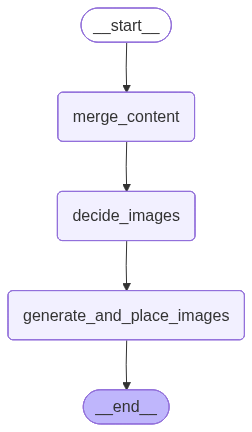

In [24]:
# build reducer subgraph
reducer_graph = StateGraph(BlogState)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()

reducer_subgraph

### create graph

In [25]:
graph = StateGraph(BlogState)

graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator", orchestrator_node)
graph.add_node("worker", worker_node) # type: ignore
graph.add_node("reducer", reducer_subgraph)

In [26]:
graph.add_edge(START, "router")
graph.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
graph.add_edge("research", "orchestrator")
graph.add_conditional_edges("orchestrator", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

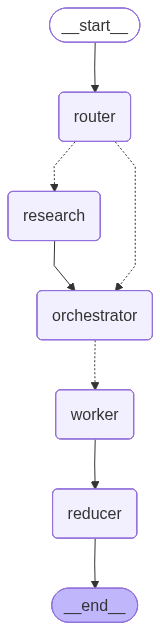

In [27]:
checkpointer = InMemorySaver()
blog_writer_agent = graph.compile(checkpointer=checkpointer)
blog_writer_agent

In [28]:
def run(topic: str, config: RunnableConfig, as_of: Optional[str] = None):
    try: 
        if as_of is None:
            as_of = date.today().isoformat()

        out = blog_writer_agent.invoke(
            {
                "topic": topic,
                "mode": "",
                "needs_research": False,
                "queries": [],
                "evidence": [],
                "plan": None,
                "as_of": as_of,
                "recency_days": 7,   # router may overwrite
                "sections": [],
                "merged_md": "",
                "md_with_placeholders": "",
                "image_specs": [],
                "final": "",
            }, config=config
        )

        plan: Plan = out["plan"]
        print("\n" + "=" * 100)
        print("TOPIC:", topic)
        print("AS_OF:", out.get("as_of"), "RECENCY_DAYS:", out.get("recency_days"))
        print("MODE:", out.get("mode"))
        print("BLOG_KIND:", plan.blog_kind)
        print("NEEDS_RESEARCH:", out.get("needs_research"))
        print("QUERIES:", (out.get("queries") or [])[:6])
        print("EVIDENCE_COUNT:", len(out.get("evidence", [])))
        if out.get("evidence"):
            print("EVIDENCE_SAMPLE:", [e.model_dump() for e in out["evidence"][:2]])
        print("TASKS:", len(plan.tasks))
        print("SAVED_MD_CHARS:", len(out.get("final", "")))
        print("=" * 100 + "\n")

        return out
    
    except Exception as e:
        snapshots = list(blog_writer_agent.get_state_history(config))
        config2 = snapshots[0].config
        out = blog_writer_agent.invoke(None, config=config2)

        plan: Plan = out["plan"]
        print("\n" + "=" * 100)
        print("TOPIC:", topic)
        print("AS_OF:", out.get("as_of"), "RECENCY_DAYS:", out.get("recency_days"))
        print("MODE:", out.get("mode"))
        print("BLOG_KIND:", plan.blog_kind)
        print("NEEDS_RESEARCH:", out.get("needs_research"))
        print("QUERIES:", (out.get("queries") or [])[:6])
        print("EVIDENCE_COUNT:", len(out.get("evidence", [])))
        if out.get("evidence"):
            print("EVIDENCE_SAMPLE:", [e.model_dump() for e in out["evidence"][:2]])
        print("TASKS:", len(plan.tasks))
        print("SAVED_MD_CHARS:", len(out.get("final", "")))
        print("=" * 100 + "\n")

        return out


In [30]:
config = RunnableConfig({"configurable":{"thread_id": "1"}})
out = run("write a blog on transformer archetecture", config=config)


TOPIC: write a blog on transformer archetecture
AS_OF: 2026-05-05 RECENCY_DAYS: 45
MODE: hybrid
BLOG_KIND: explainer
NEEDS_RESEARCH: True
QUERIES: ['Transformer architecture advancements 2026', 'Recent transformer model releases', 'Transformer applications in natural language processing', 'State-of-the-art transformer architectures', 'Transformer-based models for computer vision', 'Comparison of transformer architectures for different tasks']
EVIDENCE_COUNT: 5
EVIDENCE_SAMPLE: [{'title': 'What Comes After Transformers: Hybrid AI Architecture in 2026', 'url': 'https://philippdubach.com/posts/the-last-architecture-designed-by-hand/', 'published_at': None, 'snippet': 'The transformer architecture is evolving rapidly, with a focus on hybrid models that combine the strengths of different paradigms. Researchers are exploring alternatives to the traditional transformer architecture, such as State-Space Models (SSMs), Mixture of Experts (MoE), and hybrid architectures that blend attention wit

In [31]:
out

{'topic': 'write a blog on transformer archetecture',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['Transformer architecture advancements 2026',
  'Recent transformer model releases',
  'Transformer applications in natural language processing',
  'State-of-the-art transformer architectures',
  'Transformer-based models for computer vision',
  'Comparison of transformer architectures for different tasks',
  'Transformer architecture limitations and challenges',
  'Transformer-based models for multimodal learning'],
 'evidence': [EvidenceItem(title='What Comes After Transformers: Hybrid AI Architecture in 2026', url='https://philippdubach.com/posts/the-last-architecture-designed-by-hand/', published_at=None, snippet='The transformer architecture is evolving rapidly, with a focus on hybrid models that combine the strengths of different paradigms. Researchers are exploring alternatives to the traditional transformer architecture, such as State-Space Models (SSMs), Mixture of Ex

In [ ]:
snapshots = list(blog_writer_agent.get_state_history(config))
snapshots

[StateSnapshot(values={'topic': 'write a blog on transformer archetecture', 'mode': 'hybrid', 'needs_research': True, 'queries': ['Transformer architecture latest advancements 2026', 'Transformer architecture applications in NLP 2026', 'Recent transformer models for language translation', 'Transformer architecture for computer vision tasks', 'State-of-the-art transformer models for text classification', 'Transformer architecture optimization techniques 2026', 'Comparison of transformer architectures for different NLP tasks'], 'evidence': [EvidenceItem(title='Transformer Architecture in 2026: From Attention to Mixture of Experts (MoE) - DEV Community', url='https://dev.to/jintukumardas/transformer-architecture-in-2026-from-attention-to-mixture-of-experts-moe-3d46', published_at='2026-04-10', snippet='The biggest weakness of the classic Transformer is that attention cost grows quadratically ($O(n^2)$) with sequence length. Doubling your context window quadruples your compute cost.', sour

In [46]:
config2 = snapshots[0].config
out = blog_writer_agent.invoke(None, config=config2)

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '[\n  {\n    "name": "GlobalImagePlan",\n    "parameters": {\n      "md_with_placeholders": "# The Evolution of Transformer Architecture: From Attention to Efficiency ## Introduction to Transformer Architecture The transformer architecture has revolutionized the field of artificial intelligence, particularly in natural language processing (NLP). At its core, the transformer model relies on a self-attention mechanism, which allows it to weigh the importance of different input elements relative to each other. This mechanism enables the model to capture long-range dependencies and contextual relationships in input sequences. The transformer architecture typically consists of an encoder-decoder structure. The encoder takes in a sequence of tokens and output

In [139]:
filename = f"2025 Job Market Trends.md"
Path(filename).write_text(snapshots[0].values["final"], encoding="utf-8")

6510